In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import utils.UVA as UVA
import utils.MVA as MVA
import utils.PCA as PCA

from sklearn.preprocessing import OneHotEncoder, StandardScaler, StandardScaler
#from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, DBSCAN
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, silhouette_samples

#from yellowbrick.cluster import KElbowVisualizer

In [37]:
# pip install threadpoolctl==3.1.0

In [38]:
#import warnings
#warnings.filterwarnings("ignore")

In [39]:
pwd

'\\\\wsl.localhost\\Ubuntu\\home\\dgaillot\\code\\openclassrooms\\openclassrooms\\projets\\projet_5'

In [40]:
#df = pd.read_csv('data/olist_rfm.csv')

df = pd.read_csv('data/clean_df_customers.csv')

In [41]:
df.head()

,mean_review_score,baby,ratio_comment_message,computers,cool_stuff,fixed_telephony,furniture_decor,musical_instruments,sports_leisure,unknown,other_categories,freight_value,frequency_medium
0,4,35.39,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17.44,1
1,4,0.00,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.76,0
2,5,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.22,1
3,3,0.00,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,27.20,1
4,5,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.9,8.72,0


In [42]:
# remove customer_unique_id
#df.drop(['customer_unique_id'], axis=1, inplace=True)
#df.head()

In [43]:
df.shape

(95399, 13)

In [44]:
df.dtypes

mean_review_score          int64
baby                     float64
ratio_comment_message    float64
computers                float64
cool_stuff               float64
fixed_telephony          float64
furniture_decor          float64
musical_instruments      float64
sports_leisure           float64
unknown                  float64
other_categories         float64
freight_value            float64
frequency_medium           int64
dtype: object

In [45]:
df.isna().sum()

mean_review_score        0
baby                     0
ratio_comment_message    0
computers                0
cool_stuff               0
fixed_telephony          0
furniture_decor          0
musical_instruments      0
sports_leisure           0
unknown                  0
other_categories         0
freight_value            0
frequency_medium         0
dtype: int64

In [46]:
quantiles = df.quantile(q=[0.25,0.5,0.75])
quantiles

,mean_review_score,baby,ratio_comment_message,computers,cool_stuff,fixed_telephony,furniture_decor,musical_instruments,sports_leisure,unknown,other_categories,freight_value,frequency_medium
0.25,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.08,0.0
0.50,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17.60,0.0
0.75,5.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.54,1.0


# Distribution

In [47]:
num_cols = df.select_dtypes(include=np.number).columns.to_list()
num_cols

['mean_review_score',
 'baby',
 'ratio_comment_message',
 'computers',
 'cool_stuff',
 'fixed_telephony',
 'furniture_decor',
 'musical_instruments',
 'sports_leisure',
 'unknown',
 'other_categories',
 'freight_value',
 'frequency_medium']

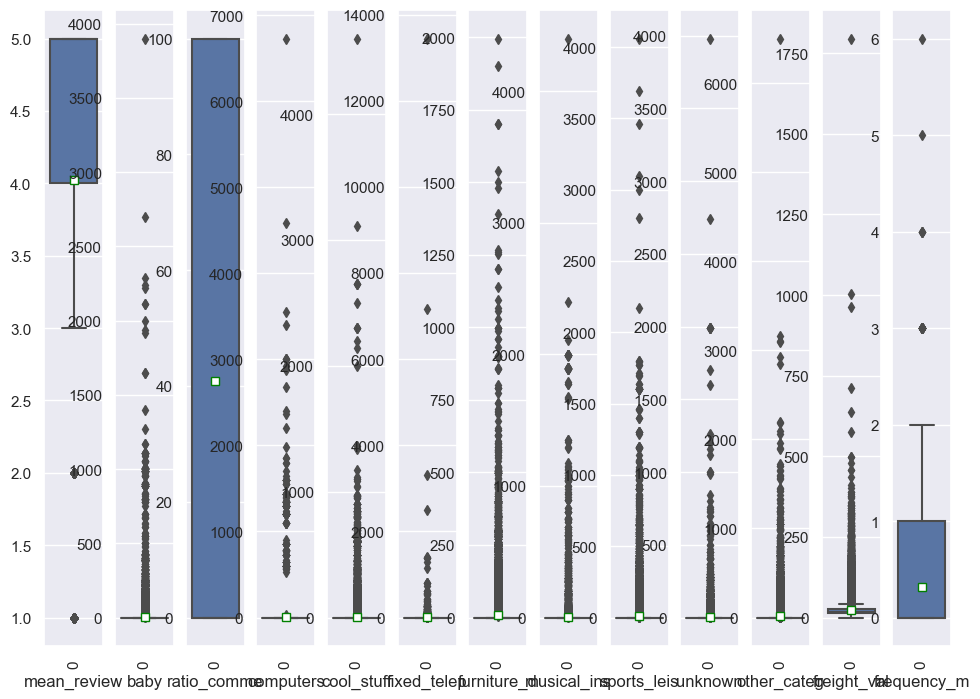

In [48]:
MVA.boxplot_nums(df, num_cols)

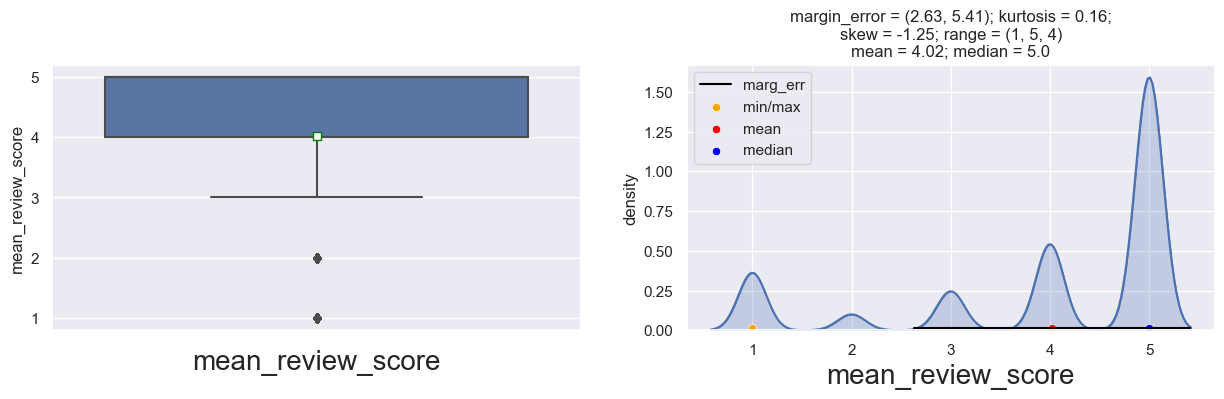

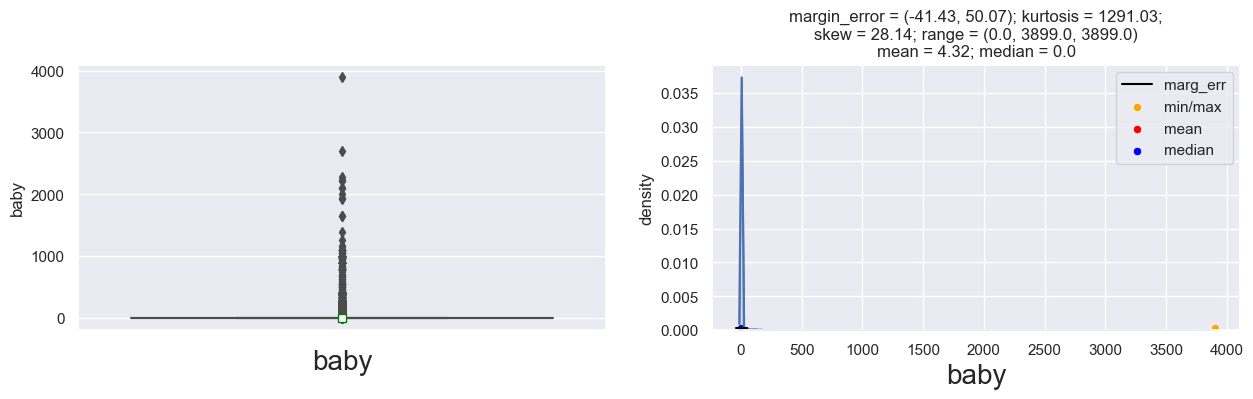

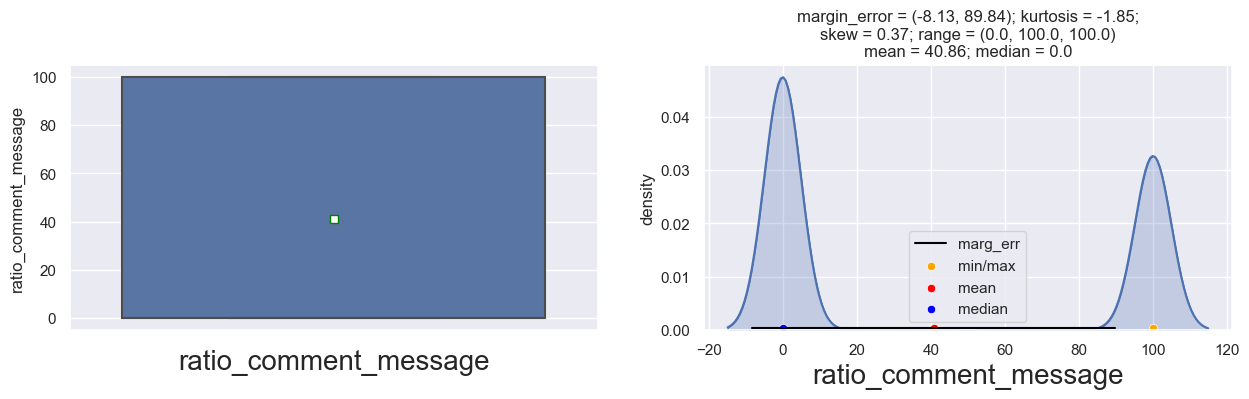

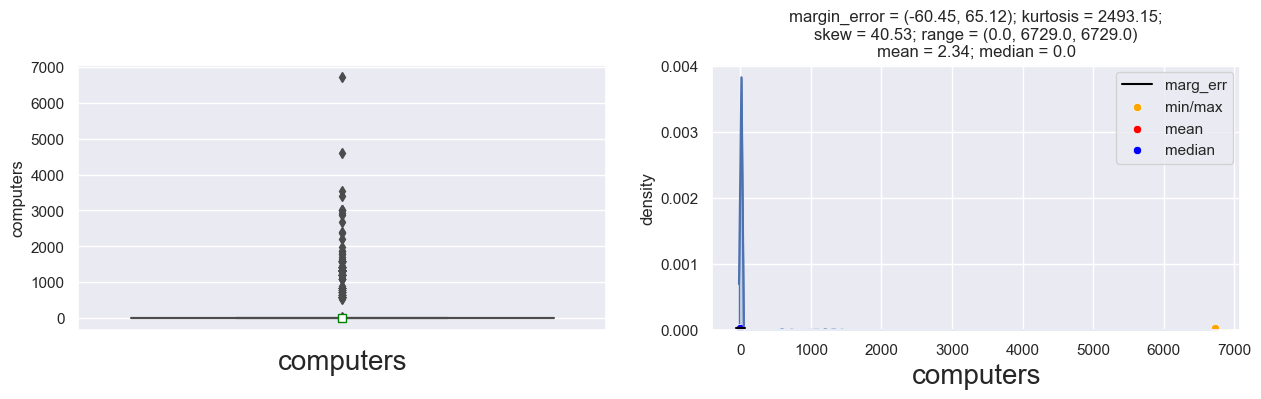

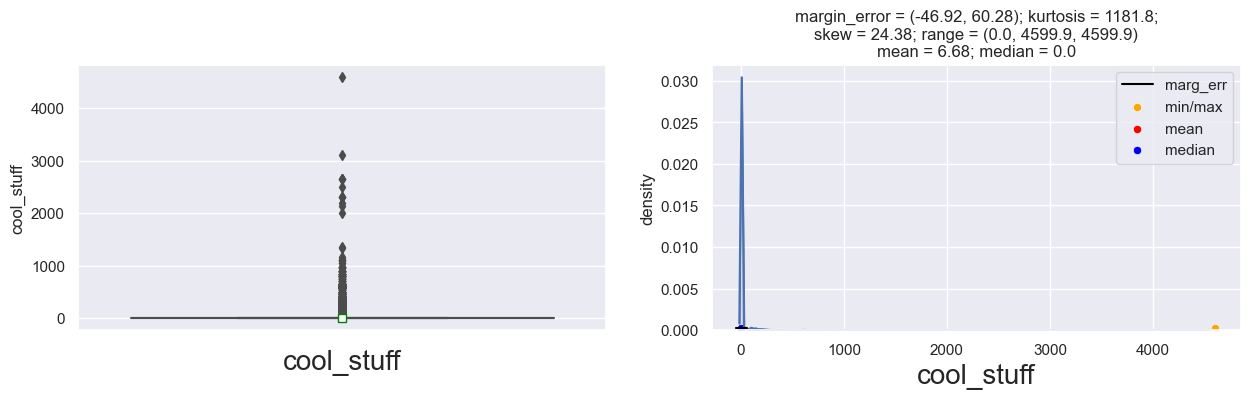

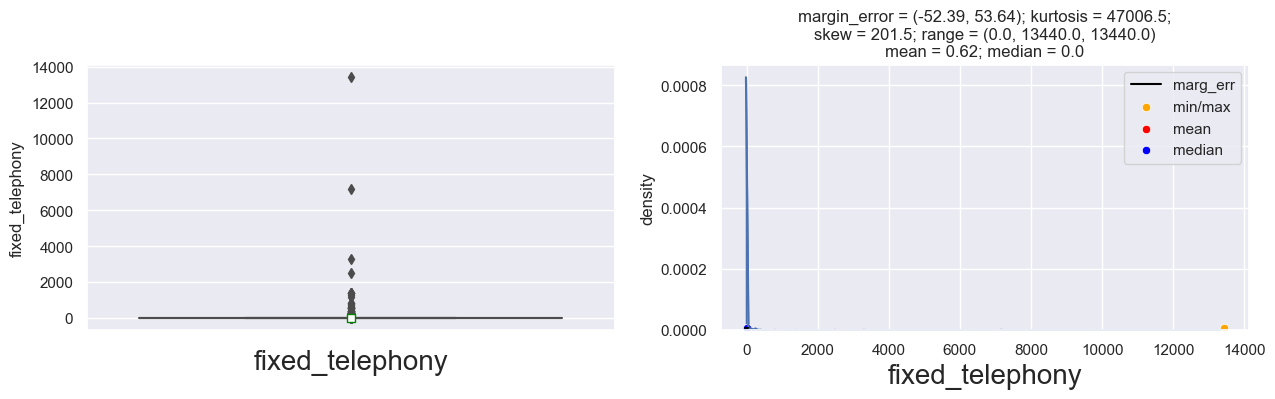

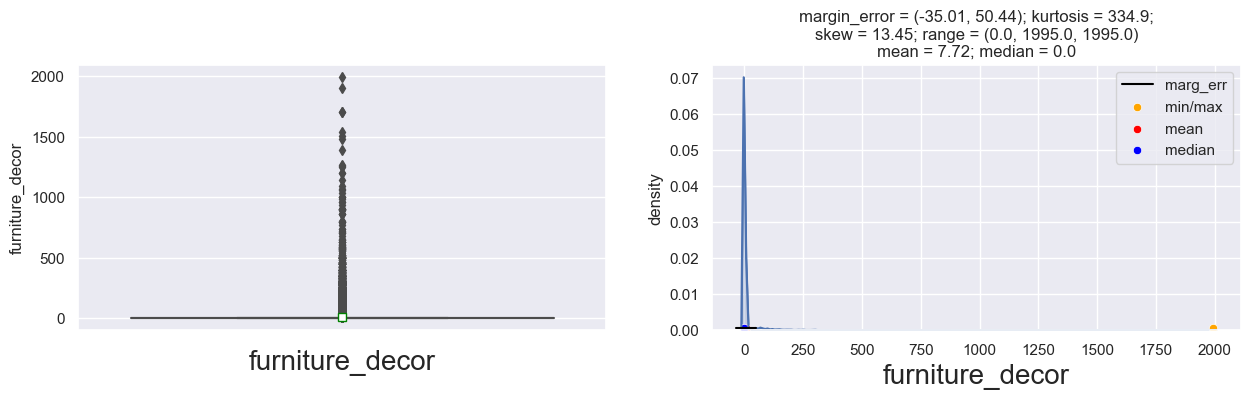

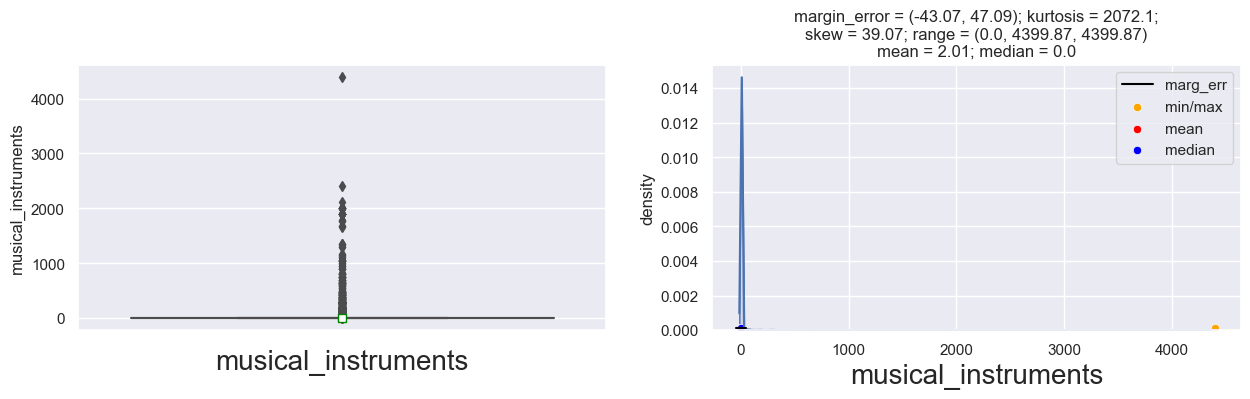

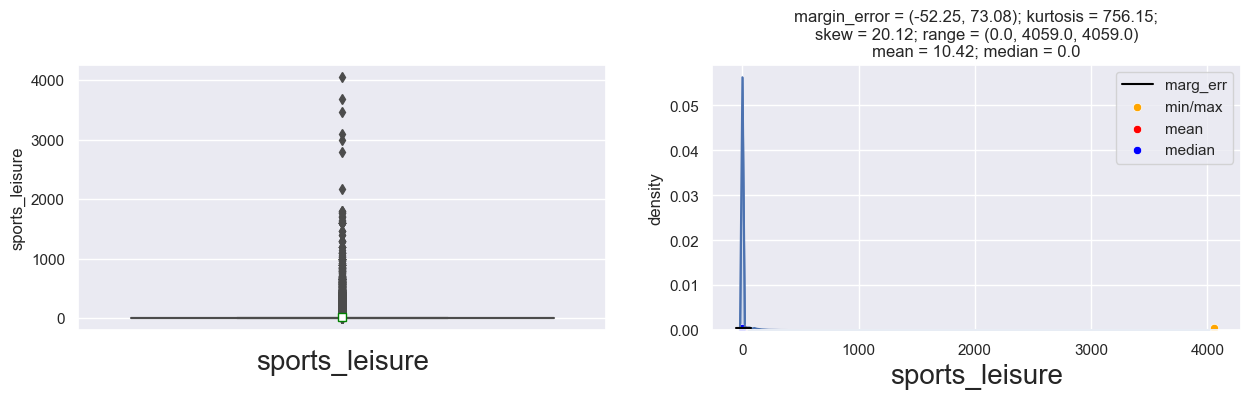

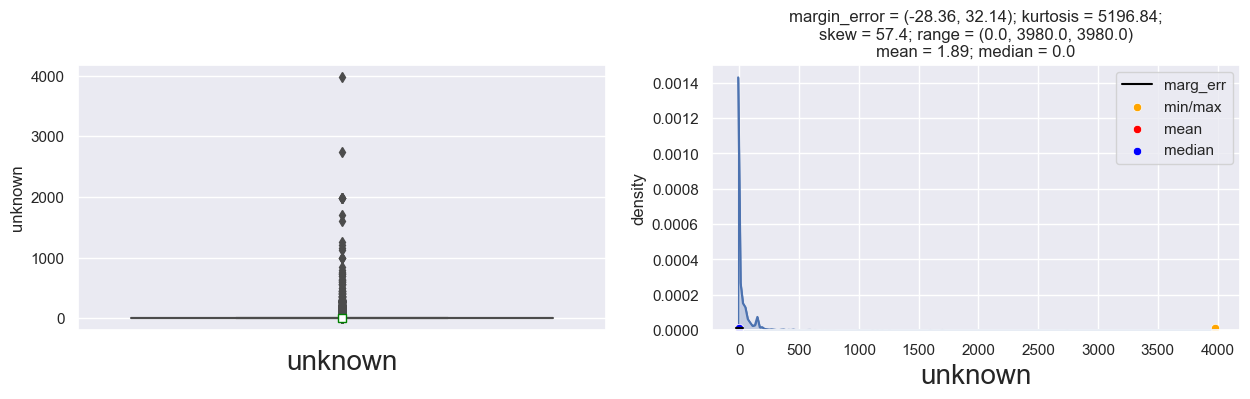

In [ ]:
UVA.num_plus(df, num_cols)

In [ ]:
MVA.heatmap_num_2(df, annot_val=True, textsize=8) #

In [ ]:
PCA.CHA(df, num_cols, label_size=12, rotation=85)

# Echantillon

In [ ]:
df_redux = df.sample(10000, random_state=1).copy()
X = df_redux.copy()
#categorical_columns = X.select_dtypes(['category','object']).columns
num_cols = X.select_dtypes(include=np.number).columns.to_list()

ss = StandardScaler()
X[num_cols] = ss.fit_transform(X[num_cols])

### X_std / echantillon

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, PowerTransformer
from sklearn.compose import ColumnTransformer

# sélection colonnes avec skewness élevée :
skewness = df.select_dtypes(include=np.number).skew()
treshold_skew = 1.0
cols_skewed = skewness[skewness > treshold_skew].index.tolist()
cols_unskewed = skewness[skewness < treshold_skew].index.tolist()

print("Colonnes numériques avec une skewness supérieure à la limite :")
print(cols_skewed)
print(cols_unskewed)
# Création du ColumnTransformer
transformer = ColumnTransformer([
    #('minmax', MinMaxScaler(), cols_skewed),
    ('power', PowerTransformer(), cols_skewed),
    ('standard', StandardScaler(), cols_unskewed)
])

X_std = pd.DataFrame(transformer.fit_transform(df), columns=df.columns)
X_std.head()

In [18]:
#X_std = PCA.clean_data(df, num_cols, impute=False, std=True)

	>>> Selected features: ['frequency_heavy', 'sellers_count', 'bed_bath_table', 'mean_pay_installments', 'furniture_decor', 'health_beauty', 'housewares', 'office_furniture', 'perfumery', 'toys', 'watches_gifts', 'other_categories', 'freight_value', 'frequency_light', 'frequency_medium']
	>>> Standardized data


In [ ]:
X_std

In [19]:
X_std

,frequency_heavy,sellers_count,bed_bath_table,mean_pay_installments,furniture_decor,health_beauty,housewares,office_furniture,perfumery,toys,watches_gifts,other_categories,freight_value,frequency_light,frequency_medium
0,-0.711205,4.432184,-0.226909,-0.710769,-0.180647,-0.183339,0.480574,-0.08847,-0.138373,-0.136198,-0.152115,-0.216530,-0.269261,1.220451,1.440315
1,-0.711205,-0.175118,-0.226909,-0.710769,-0.180647,-0.183339,-0.136963,-0.08847,3.776828,-0.136198,-0.152115,-0.216530,-0.036748,1.220451,-0.658266
2,-0.711205,-0.175118,-0.226909,0.036052,-0.180647,-0.183339,-0.136963,-0.08847,-0.138373,-0.136198,-0.152115,-0.216530,-0.191465,-0.752066,1.440315
3,-0.711205,-0.175118,-0.226909,-0.710769,-0.180647,-0.183339,-0.136963,-0.08847,-0.138373,-0.136198,-0.152115,-0.216530,0.157305,-0.752066,1.440315
4,-0.711205,-0.175118,-0.226909,-0.710769,-0.180647,-0.183339,-0.136963,-0.08847,-0.138373,-0.136198,-0.152115,0.063124,-0.650373,1.220451,-0.658266
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95394,-0.711205,-0.175118,-0.226909,0.036052,-0.180647,0.813732,-0.136963,-0.08847,-0.138373,-0.136198,-0.152115,-0.216530,-0.459817,-0.752066,1.440315
95395,1.324691,-0.175118,-0.226909,0.036052,-0.180647,-0.183339,-0.136963,-0.08847,-0.138373,-0.136198,-0.152115,-0.216530,-0.153005,-0.752066,-0.658266
95396,1.324691,-0.175118,-0.226909,0.782873,-0.180647,-0.183339,-0.136963,-0.08847,-0.138373,-0.136198,-0.152115,-0.216530,1.810248,-0.752066,-0.658266
95397,1.324691,-0.175118,-0.226909,0.409463,-0.180647,-0.183339,-0.136963,-0.08847,-0.138373,-0.136198,-0.152115,-0.216530,2.516530,-0.752066,-0.658266


# PCA

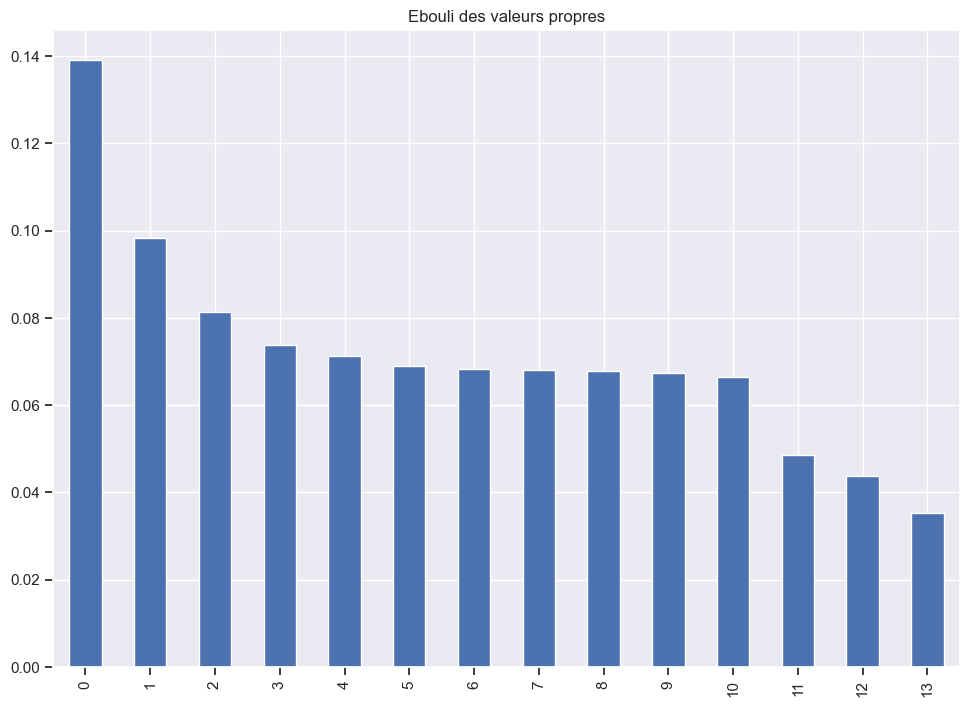

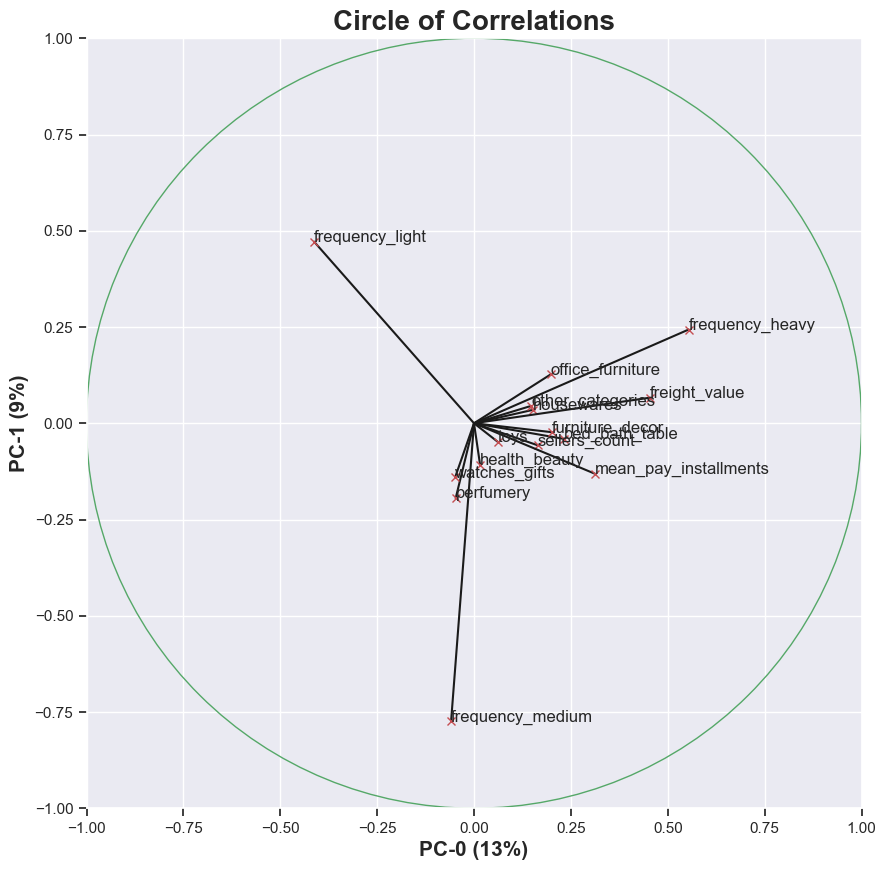

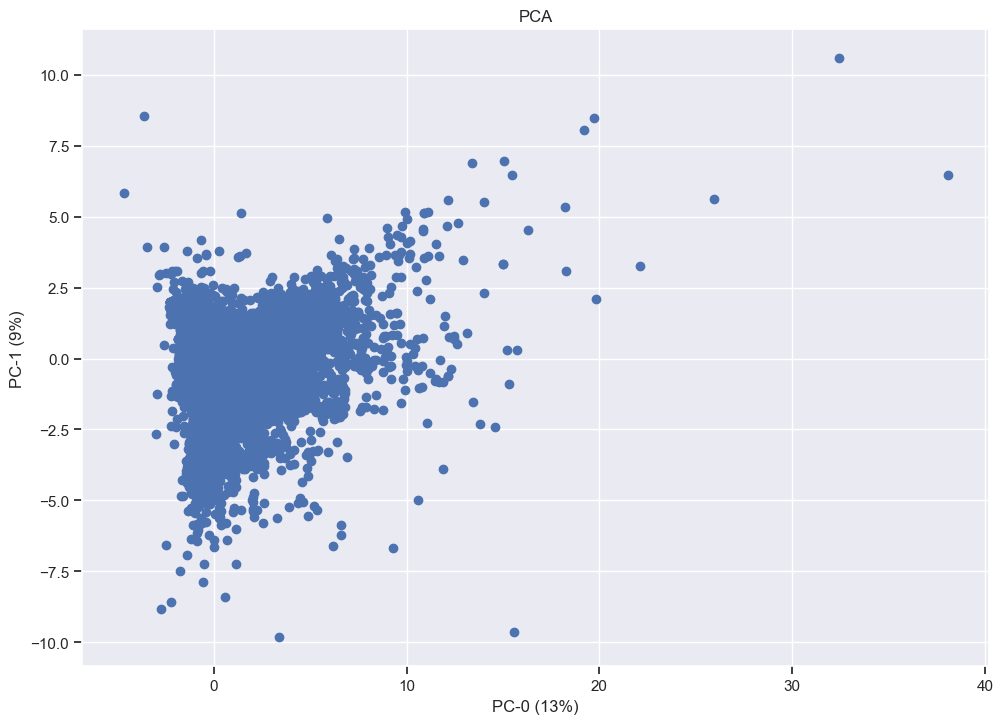

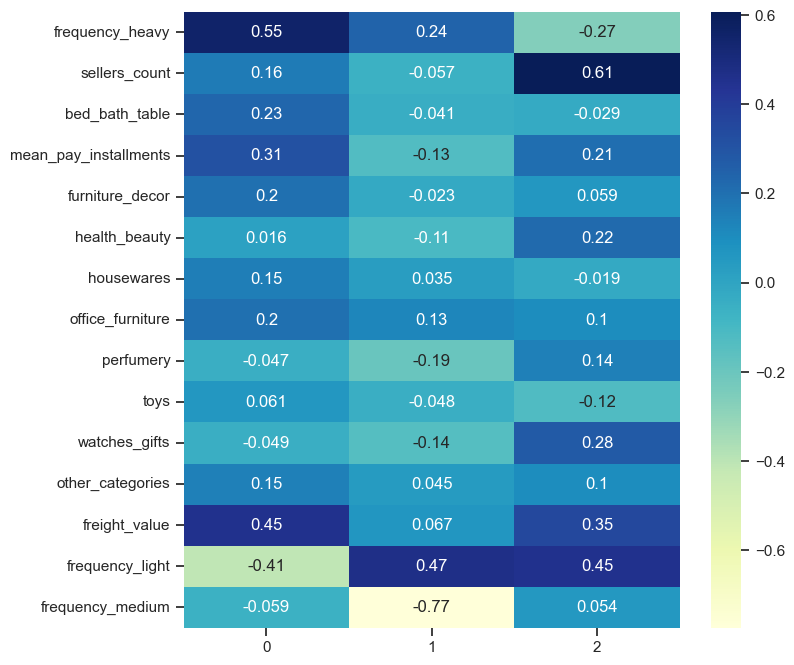

Résumé PCA
Total: 14 composants
----------------------------------------
Moyenne de la variance expliquée : 0.071
----------------------------------------
    explained variance  cumulative
1             0.139011    0.139011
2             0.098308    0.237319
3             0.081369    0.318688
4             0.073656    0.392343
5             0.071301    0.463644
6             0.069063    0.532707
7             0.068366    0.601072
8             0.067925    0.668998
9             0.067690    0.736688
10            0.067398    0.804086
11            0.066476    0.870562
12            0.048462    0.919025
13            0.043803    0.962827
14            0.035159    0.997986
----------------------------------------


,PC-0,PC-1,PC-2,PC-3,PC-4,PC-5,PC-6,PC-7,PC-8,PC-9,PC-10,PC-11,PC-12,PC-13
frequency_heavy,0.554055,0.243464,-0.266246,-0.081672,0.081010,0.001732,0.008787,-0.007680,0.007347,-0.009612,-0.094046,-0.406161,-0.217968,-0.053675
sellers_count,0.164698,-0.057358,0.607494,-0.429934,-0.177645,0.019422,0.010428,0.023208,0.011233,0.202330,0.170957,-0.255073,-0.424637,-0.146437
bed_bath_table,0.232142,-0.040558,-0.028952,-0.589120,0.320645,-0.092191,0.223266,0.132896,-0.167896,-0.200653,0.219692,0.216404,0.459159,-0.208102
mean_pay_installments,0.313192,-0.131647,0.206103,0.148123,0.495023,0.030291,0.025698,-0.013231,-0.002873,0.021528,-0.303738,0.564121,-0.397589,0.065575
furniture_decor,0.201517,-0.023297,0.059234,-0.178151,-0.418917,-0.111783,-0.313426,-0.450261,0.124700,-0.135937,-0.477157,0.213042,0.205766,-0.291866
health_beauty,0.015806,-0.108764,0.219103,0.320158,0.092006,-0.581677,0.548733,-0.111237,0.148388,0.043573,-0.152195,-0.232494,0.139124,-0.237948
housewares,0.151840,0.034804,-0.018874,0.099552,-0.066853,-0.108429,-0.267255,0.617344,0.580506,0.230794,0.062071,0.143811,0.128848,-0.255562
office_furniture,0.198092,0.127015,0.100135,0.428242,-0.151747,-0.172321,-0.237993,0.039253,-0.482864,-0.211821,0.427873,0.150839,-0.078081,-0.387753
perfumery,-0.047299,-0.194829,0.144771,0.033553,0.034012,0.089365,-0.144117,0.474343,-0.512278,0.079487,-0.552157,-0.262070,0.183008,-0.083680
toys,0.060649,-0.047788,-0.123489,0.028126,0.189882,0.000844,-0.154911,-0.321131,-0.182641,0.841375,0.125647,0.018988,0.204392,-0.124939


In [20]:
PCA.myPCA(X_std)

# 

PCA.myPCA(X)

In [21]:
#MVA.heatmap_num_2(X_enc)

In [22]:
#num_cols_Xenc = X_enc.select_dtypes(include=np.number).columns.to_list()

In [23]:
#PCA.CHA(X_enc, num_cols_Xenc)

# K-Means

In [24]:
# print avancement au fur et à mesure

### Elbow method

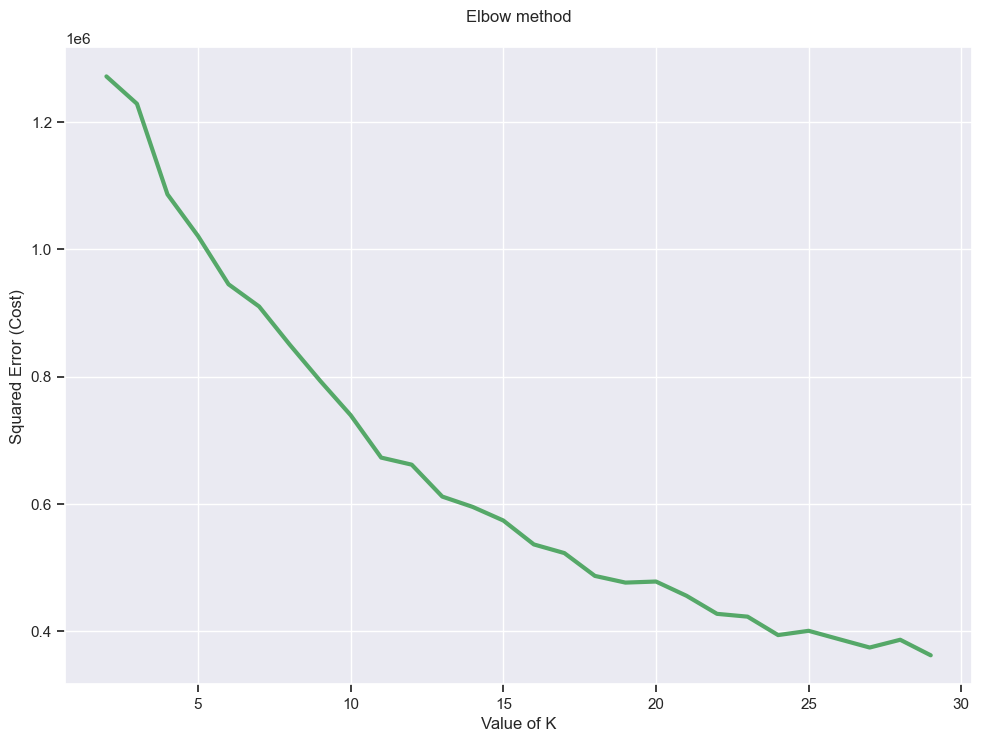

In [26]:
cost =[]
test_clusters = [i for i in range(2, 30)]
for i in test_clusters:
    #cls=KMeans(n_clusters=i,n_init=50,init='k-means++')
    cls = KMeans(n_clusters=i)
    cls.fit(X_std)
    cost.append(cls.inertia_)    


plt.plot(test_clusters, cost, color ='g', linewidth ='3')
plt.title("Elbow method\n")
plt.xlabel("Value of K")
plt.ylabel("Squared Error (Cost)")
#plt.axvline(x=nb_groupes_de_points, ymin=0, ymax=1, color="red")
plt.show()

In [27]:
# recherche nb optimum de clusters
## inertia = Sum of squared distances of samples to their closest cluster center

In [28]:
inertia = {}
dict_kmeans = {}
for k in range(1,25):
    print(k)
    kmeans = KMeans(n_clusters=k,
                   verbose=1,
                   random_state=0
                   ).fit(X_std)
    inertia[k] = kmeans.inertia_
    dict_kmeans[k] = kmeans

1
Initialization complete
Iteration 0, inertia 1742628.388360475.
Iteration 1, inertia 1430985.0.
Converged at iteration 1: strict convergence.
2
Initialization complete
Iteration 0, inertia 1588566.1017290656.
Iteration 1, inertia 1277370.3268770035.
Iteration 2, inertia 1272118.305134348.
Iteration 3, inertia 1272078.4222900306.
Converged at iteration 3: center shift 1.0620601247771292e-05 within tolerance 9.999999999998395e-05.
3
Initialization complete
Iteration 0, inertia 1401126.4268579623.
Iteration 1, inertia 1254267.5907601202.
Iteration 2, inertia 1239919.7804771583.
Iteration 3, inertia 1229909.443067077.
Iteration 4, inertia 1227583.3471625275.
Iteration 5, inertia 1226839.7425053387.
Iteration 6, inertia 1226403.243911181.
Iteration 7, inertia 1226138.9215568786.
Iteration 8, inertia 1225999.7884843359.
Iteration 9, inertia 1225931.5815227898.
Iteration 10, inertia 1225896.2284954572.
Iteration 11, inertia 1225862.315422169.
Iteration 12, inertia 1225809.1460058999.
Iterat

<AxesSubplot:title={'center':'Kmeans : Comparaison de la somme des inerties en fonction du nombre de clusters'}>

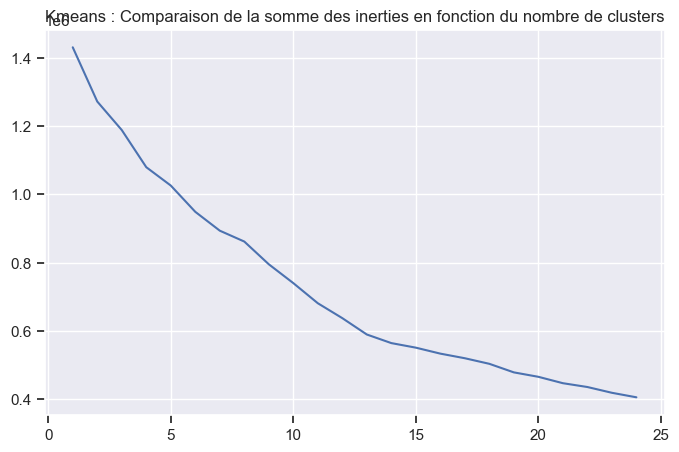

In [29]:
plt.figure(figsize=(8,5))
plt.title('Kmeans : Comparaison de la somme des inerties en fonction du nombre de clusters')
sns.lineplot(list(inertia.keys()),
             list(inertia.values())
            )


In [30]:
inertia = {}
dict_kmeans = {}

nb_boucles=3
max_clusters = 25

for k in range(1,nb_boucles+1):
    print('Boucle ',k)
    for i in range(1,max_clusters+1):
        kmeans = KMeans(n_clusters=i,
                       verbose=1,
                       #n_jobs=-1
                       ).fit(X_std)
        inertia[(k,i)] = kmeans.inertia_
        dict_kmeans[k,i] = kmeans

Boucle  1
Initialization complete
Iteration 0, inertia 2045087.495569048.
Iteration 1, inertia 1430985.0.
Converged at iteration 1: strict convergence.
Initialization complete
Iteration 0, inertia 1776806.692342777.
Iteration 1, inertia 1342858.2541611968.
Iteration 2, inertia 1336986.9770006626.
Iteration 3, inertia 1335829.51129406.
Iteration 4, inertia 1335485.5972243836.
Iteration 5, inertia 1335370.2089191894.
Iteration 6, inertia 1335322.437491032.
Iteration 7, inertia 1335306.8012026926.
Iteration 8, inertia 1335297.4535515085.
Iteration 9, inertia 1335292.561856311.
Iteration 10, inertia 1335286.1060124699.
Iteration 11, inertia 1335283.1910648746.
Iteration 12, inertia 1335280.1373015947.
Iteration 13, inertia 1335272.10334509.
Iteration 14, inertia 1335267.2275720218.
Iteration 15, inertia 1335263.080604686.
Iteration 16, inertia 1335258.6308654496.
Iteration 17, inertia 1335256.529360694.
Iteration 18, inertia 1335254.8725189443.
Iteration 19, inertia 1335253.890059527.
Iter

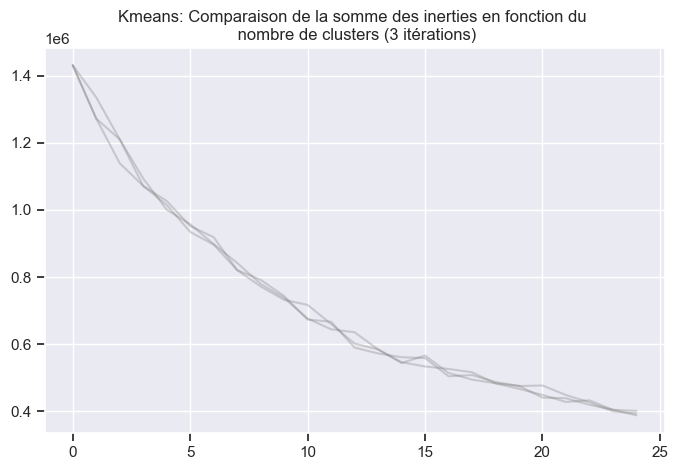

In [31]:
chaine = 'Kmeans: Comparaison de la somme des inerties en fonction du \n nombre de clusters (' + str(nb_boucles) + ' itérations)'
plt.figure(figsize=(8,5))
plt.title(chaine)
for i in range(0,nb_boucles):
    index_plot = [cluster+i*(max_clusters) for cluster in list(range(0,max_clusters))][0:max_clusters]
    sous_liste = [list(inertia.values())[index] for index in index_plot]
    sns.lineplot(list(range(0,max_clusters)),
                 sous_liste, alpha=1/nb_boucles, color='grey')

### coefficient de silhouette

In [32]:
silhouettes_kmeans = {}
max_clusters = 15
for i in range(2,max_clusters):
    sil_var = silhouette_score(
                                X = X_std,
                                labels= list(dict_kmeans[(1,i)].labels_))
    print(sil_var)
    #print(dict_kmeans[(1,i)].labels_)
    silhouettes_kmeans[i] = sil_var

0.5634641872758052
0.27612138265838493
0.30540319031888374
0.3337255773160259
0.343216269497454
0.3530048036849621
0.36381596787884046
0.3795198020806762
0.3971673251567384
0.36602208746060017
0.4151685174938493
0.4271655045897637
0.43075116623728044


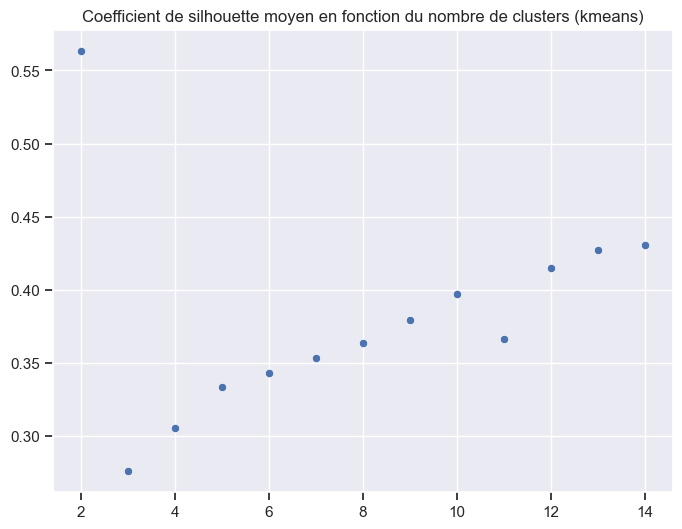

In [33]:
plt.figure(figsize=(8,6)),
plt.title('Coefficient de silhouette moyen en fonction du nombre de clusters (kmeans)')
sns.scatterplot(x = list(silhouettes_kmeans.keys()),
               y = list(silhouettes_kmeans.values()))
plt.show()

In [34]:
for key, value in silhouettes_kmeans.items():
    if value == max(silhouettes_kmeans.values()):
        print('le coefficient de silhouette est maximal pour {} clusters (score = {})'.format(key, value))
        nb_clusters = key

le coefficient de silhouette est maximal pour 2 clusters (score = 0.5634641872758052)


In [35]:
nb_clusters

2

In [ ]:
silhouettes_kmeans.values().sort_values(ascending=True)

### Model

In [37]:
kmeans = KMeans(n_clusters=3, 
                verbose=1, 
                random_state=0,
               #n_jobs=-1
               ).fit(X_std)

Initialization complete
Iteration 0, inertia 1498717.1250998331.
Iteration 1, inertia 1279595.9569842566.
Iteration 2, inertia 1224318.2997809243.
Iteration 3, inertia 1207191.588706234.
Iteration 4, inertia 1203422.7079302156.
Iteration 5, inertia 1201386.6552422848.
Iteration 6, inertia 1199726.40009899.
Iteration 7, inertia 1198287.942540251.
Iteration 8, inertia 1196862.3483922526.
Iteration 9, inertia 1195078.7685215324.
Iteration 10, inertia 1192034.5461341606.
Iteration 11, inertia 1184351.7451697867.
Iteration 12, inertia 1155438.1830308675.
Iteration 13, inertia 1140746.2498912467.
Iteration 14, inertia 1140531.4718180818.
Iteration 15, inertia 1140363.9616132516.
Iteration 16, inertia 1140359.8842862195.
Converged at iteration 16: center shift 6.992990937132716e-06 within tolerance 0.00010000000000001086.


In [38]:
kmeans.labels_

array([2, 0, 2, ..., 1, 1, 0])

In [39]:
##wcss stands for within cluster sum of squares


#wcss={}

#for k in range(2,15):
#    km = KMeans(n_clusters=k, init='k-means++', max_iter=1000 , random_state=20)
#    km = km.fit(X)
#    wcss[k] = silhouette_score(X, km.labels_)
    
##Plot graph for the wcss values and the number of clusters

#sns.pointplot(x=list(wcss.keys()), y=list(wcss.values()))
#plt.xlabel('Number of clusters K')
#plt.ylabel('Sum of square distances')
#plt.title('Elbow method for optimal K')
#plt.show()

In [40]:
# score de silhouette
#  sklearn.metrics.silhouette_score(X, labels, *, metric='euclidean', sample_size=None, random_state=None, **kwds)[source]

## T-SNE

In [41]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=0)

In [ ]:
tsne_result = tsne.fit_transform(X_std)

In [ ]:
tsne_result.shape

In [ ]:
# Représentation via T-SNE
plt.figure(figsize=(8,8))
plt.title('Représentation de la séparation des données du DBSCAN via T-SNE')
sns.scatterplot(tsne_result[:,0], tsne_result[:,1])

# DBscan

In [ ]:
dbs = DBSCAN(eps = 1, 
             min_samples=5,
               n_jobs=-1
            ).fit(X_std.copy())

In [ ]:
dbs.labels_

In [ ]:
# Représentation via T-SNE
plt.figure(figsize=(8,8))
plt.title('Représentation de la séparation des données du DBSCAN via T-SNE')
sns.scatterplot(tsne_result[:,0], tsne_result[:,1], dbs.labels_)

In [ ]:
# https://medium.com/@mohantysandip/a-step-by-step-approach-to-solve-dbscan-algorithms-by-tuning-its-hyper-parameters-93e693a91289
# silhouette to eps distance

# silhouette score gives the avg value for all the samples.
# this gives a perspective into the density and separation of the formed clusters

#range_eps = np.arange(0.1, 1.1, 0.1)
range_eps = np.arange(1, 10, 1)
range_eps

In [ ]:
dict = {
    "eps_value" :[]
    ,"silhouette_avg" :[]
    }

for i in range_eps:
    #print("eps value is " +str(i))
    db= DBSCAN(eps=i, min_samples=5, n_jobs=-1).fit(X_std)
    core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
    core_samples_mask[db.core_sample_indices_] = True
    labels = db.labels_
    #print(set(labels))
    silhouette_avg = silhouette_score(X_std, labels)
    dict["eps_value"].append(i)
    dict["silhouette_avg"].append(silhouette_avg)
    #print("For eps value = "+str(i), labels,
    #      "The average silhouette_score is : ", silhouette_avg)

eps_df = pd.DataFrame.from_dict(dict)
eps_df.sort_values(by="silhouette_avg", ascending=False)

In [ ]:
eps_max_silhouette = float(eps_df.sort_values(by="silhouette_avg", ascending=False).head(1)['eps_value'])
eps_max_silhouette

In [ ]:
# find the 'min_samples' hyper parameter through right cluster formation method

min_samples = np.arange(1, 11, 1)
min_samples

In [ ]:
dict2 = {
    "min_sample_value" :[]
    ,"nb_clusters" :[]
    }

for i in min_samples:
    db= DBSCAN(eps=eps_max_silhouette, min_samples=i, n_jobs=-1).fit(X_enc)
    core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
    core_samples_mask[db.core_sample_indices_] = True
    # Ignoring the label '-1' as its for the outliers
    labels = set([label for label in db.labels_ if label >=0])
    dict2["min_sample_value"].append(i)
    dict2["nb_clusters"].append(str(len(set(labels))))
    #print("For eps value = "+str(i), labels,
    #      "The average silhouette_score is : ", silhouette_avg)

min_samples_df = pd.DataFrame.from_dict(dict2)
min_samples_df.sort_values(by="nb_clusters", ascending=False) 

In [ ]:
### compute DBSCAN with new values :
dbs_2 = DBSCAN(eps= 2, 
             min_samples= 7,
               n_jobs= -1
            ).fit(X_enc.copy())
dbs_2.labels_

In [ ]:
# Représentation via T-SNE
plt.figure(figsize=(8,8))
plt.title('Représentation de la séparation des données du DBSCAN via T-SNE')
sns.scatterplot(tsne_result[:,0], tsne_result[:,1], dbs_2.labels_)

## SMOTE-NC

In [ ]:
# https://medium.com/analytics-vidhya/smote-nc-in-ml-categorization-models-fo-imbalanced-datasets-8adbdcf08c25

### Clustering hiérarchique

In [ ]:
nb_clusters_agg = nb_clusters

In [ ]:
cah = AgglomerativeClustering(n_clusters = nb_clusters_agg
                             ).fit(X.copy())


In [ ]:
graph = pd.DataFrame(data = [T[:,0], T[:,1], dict_kmeans[(1,11)].labels_]).T
graph.columns = ['X', 'Y', 'label_kmeans']

In [ ]:
graph['x_pca'] = x_show
graph['y_pca'] = y_show
graph['z_pca'] = z_show

In [ ]:
graph

In [ ]:
plt.figure(figsize=(10,10))
plt.title('Représentation de la séparation des données du CAH via T-SNE')
sns.scatterplot(graph['X'], 
                graph['Y'], 
                hue = cah.labels_, 
                legend='full',
               palette=sns.color_palette("hls",nb_clusters_agg))
plt.legend(loc='upper left', labels=graph['label_kmeans'].unique())
plt.show()

In [ ]:
## ne pas utiliser PCA (permet de voir cassure) => focus TSNE (x y z)
## dbscan sur 3
# visualisation : tsne + labels/couleurs, scatterplot
# /!\ scaling / encoding données : dans la préparation des données, modelisation = modeles uniquement

In [ ]:
# ajouter features
# chercher meilleur parametrage 
# pour kmeans et pour dbscan
# /!\ responsable pédagogique